In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt


In [4]:
import seaborn as sns

In [5]:
from sklearn.datasets import load_iris

In [6]:
from sklearn.model_selection import train_test_split

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [10]:
from sklearn.pipeline import Pipeline

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [12]:
###CODE
iris=load_iris()

In [13]:
df=pd.DataFrame(iris.data,
                columns=iris.feature_names)

In [14]:
df["species"] = iris.target

In [15]:
df["species_name"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})


In [17]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,Virginica
146,6.3,2.5,5.0,1.9,2,Virginica
147,6.5,3.0,5.2,2.0,2,Virginica
148,6.2,3.4,5.4,2.3,2,Virginica


In [18]:
print("Dataset Shape:",df.shape)

Dataset Shape: (150, 6)


In [21]:
print(df.columns.tolist())

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species', 'species_name']


In [22]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name             str
dtype: object

In [24]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [25]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

In [27]:
df["species_name"].value_counts()

species_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

### Initial Observations

- The dataset contains 150 observations.
- There are 4 numerical input features.
- There are 3 flower species/classes.
- Each species contains 50 observations.
- No missing/null values are present.
- The dataset is balanced across the three classes.

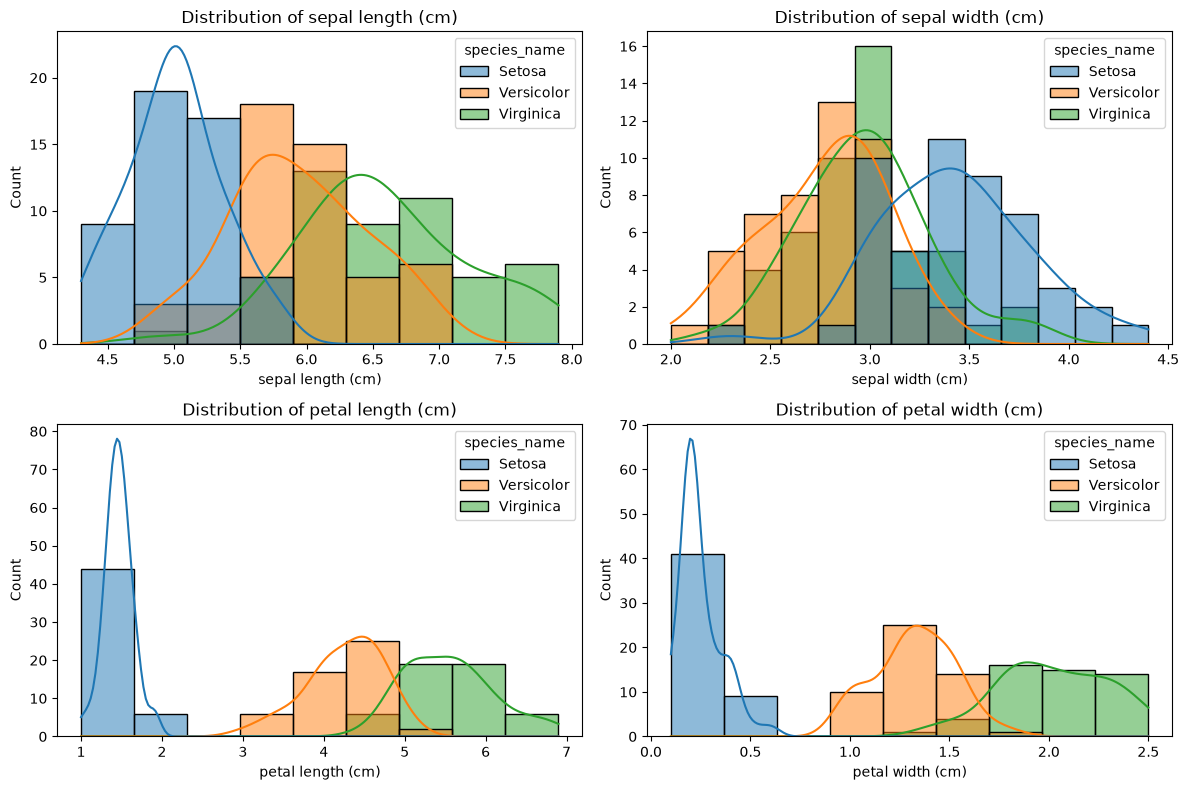

In [28]:
features = iris.feature_names

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.ravel(), features):
    sns.histplot(
        data=df,    #source of data
        x=feature,  #feature currently being processed goes on X-axis
        hue="species_name",  #seperating the histogram according to the flower species
        kde=True,  #It adds a smooth curve showing the approximate distribution of the data
        ax=ax
    )
    ax.set_title(f"Distribution of {feature}")

plt.tight_layout() #makes the figure cleaner.
plt.show()

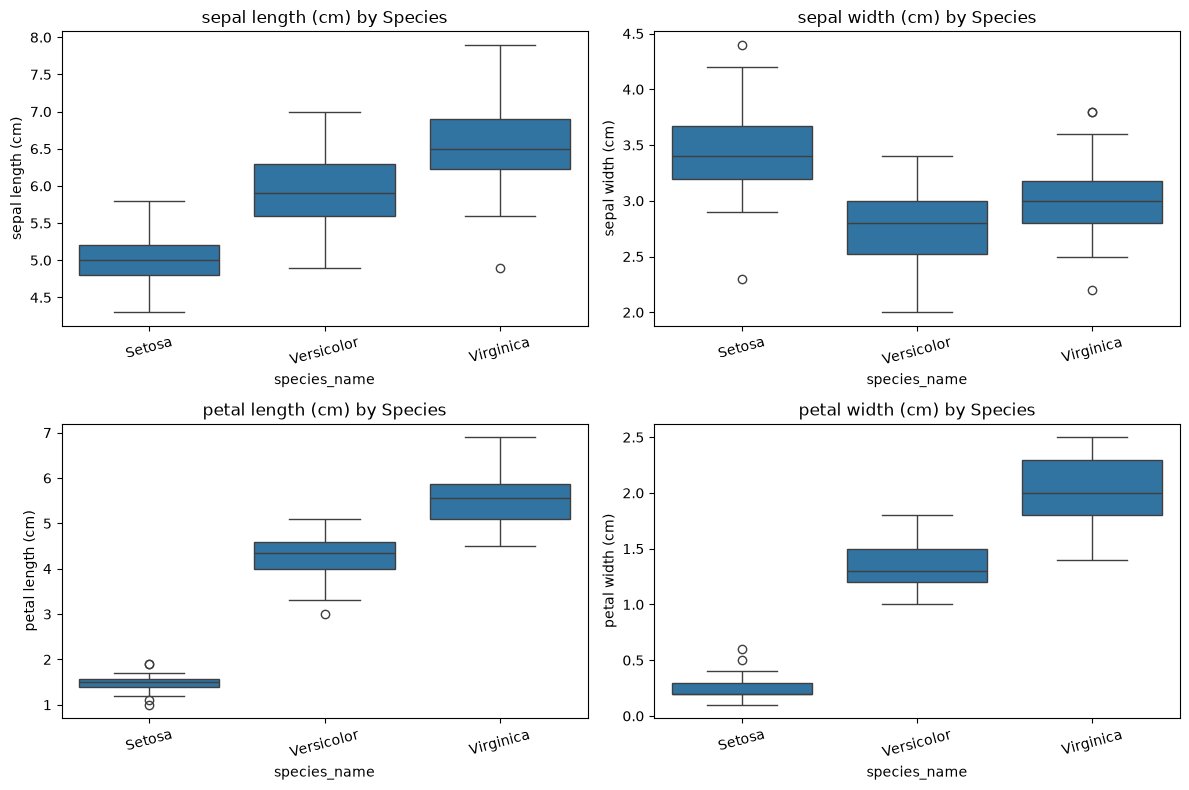

In [29]:
plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    
    sns.boxplot(
        data=df,
        x="species_name",
        y=feature
    )
    
    plt.title(f"{feature} by Species")
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Box Plot Observations

The box plots show the distribution and variability of each feature across
the three species.

Petal length and petal width show the clearest differences between classes,
making them highly discriminative features for classification.

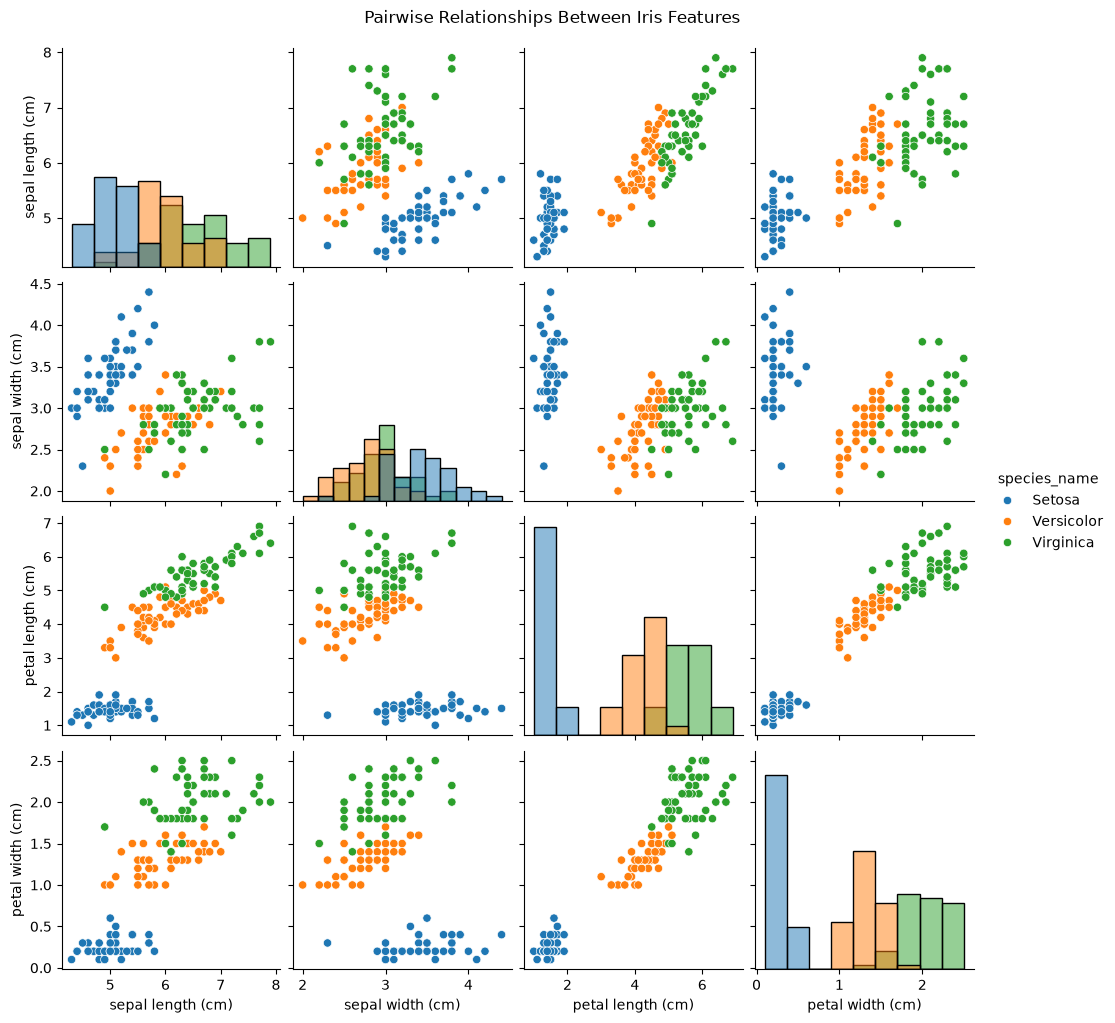

In [31]:
sns.pairplot(
    df,
    vars=features,
    hue="species_name",
    diag_kind="hist"
)

plt.suptitle(
    "Pairwise Relationships Between Iris Features",
    y=1.02
)

plt.show()

From the pairplot, petal length and petal width show strong separation between the Iris species. Setosa is particularly well separated, while Versicolor and Virginica show some overlap.

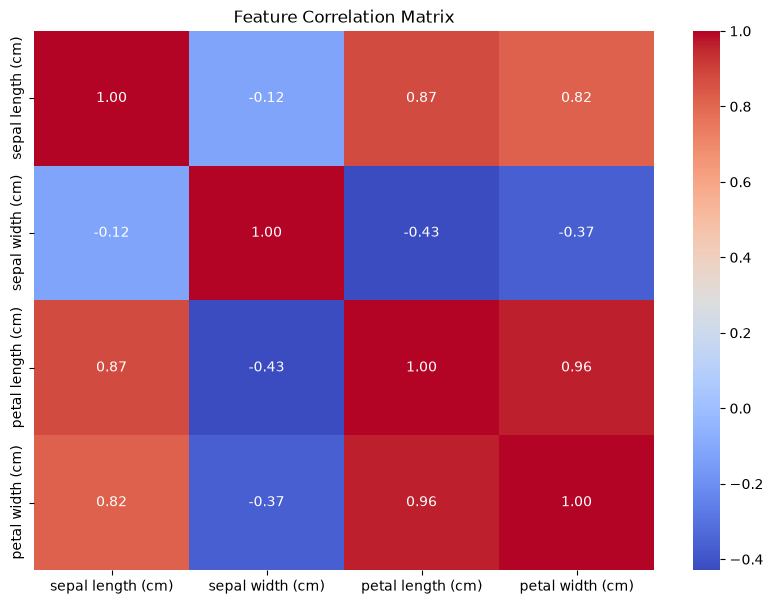

In [30]:
plt.figure(figsize=(10, 7))

correlation_matrix = df[features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

In [32]:
##FEATURES AND TARGET
X = df[features]
y = df["species"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y  #ensures that the training and testing datasets maintain approximately the same class distribution as the original dataset.
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


## Model 1: Logistic Regression

Logistic Regression is used as a strong baseline classification algorithm.
Although its name contains "regression", it is commonly used for
classification problems.

Feature scaling is applied before training.

In [34]:
#MODEL-1
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

In [35]:
#EVALUATION
print("Logistic Regression")
print("-" * 50)

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Precision:",
      precision_score(y_test, y_pred_lr, average="weighted"))

print("Recall:",
      recall_score(y_test, y_pred_lr, average="weighted"))

print("F1-Score:",
      f1_score(y_test, y_pred_lr, average="weighted"))

Logistic Regression
--------------------------------------------------
Accuracy: 0.9333333333333333
Precision: 0.9333333333333333
Recall: 0.9333333333333333
F1-Score: 0.9333333333333333


In [36]:
#CLASSIFICATION REPORT
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## Model 2: K-Nearest Neighbours (KNN)

KNN classifies a sample based on the classes of its nearest neighbouring
data points.

Here, k = 5 is used.

Feature scaling is important for KNN because it uses distance calculations.

In [37]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

In [40]:
#EVALUATION:
print("K-Nearest Neighbours")
print("-" * 50)

print("Accuracy:",
      accuracy_score(y_test, y_pred_knn))

print("Precision:",
      precision_score(y_test, y_pred_knn, average="weighted"))

print("Recall:",
      recall_score(y_test, y_pred_knn, average="weighted"))

print("F1-Score:",
      f1_score(y_test, y_pred_knn, average="weighted"))

K-Nearest Neighbours
--------------------------------------------------
Accuracy: 0.9333333333333333
Precision: 0.9444444444444445
Recall: 0.9333333333333333
F1-Score: 0.9326599326599326


In [41]:
#CLASSIFICATION:
print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## Model 3: Decision Tree

Decision Tree is a nonlinear classification algorithm that makes decisions
using a sequence of feature-based rules.

Decision Trees are easy to interpret and do not require feature scaling.

In [42]:
dt_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [43]:
print("Decision Tree")
print("-" * 50)

print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("Precision:",
      precision_score(y_test, y_pred_dt, average="weighted"))

print("Recall:",
      recall_score(y_test, y_pred_dt, average="weighted"))

print("F1-Score:",
      f1_score(y_test, y_pred_dt, average="weighted"))

Decision Tree
--------------------------------------------------
Accuracy: 0.9666666666666667
Precision: 0.9696969696969696
Recall: 0.9666666666666667
F1-Score: 0.9665831244778613


In [44]:
print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



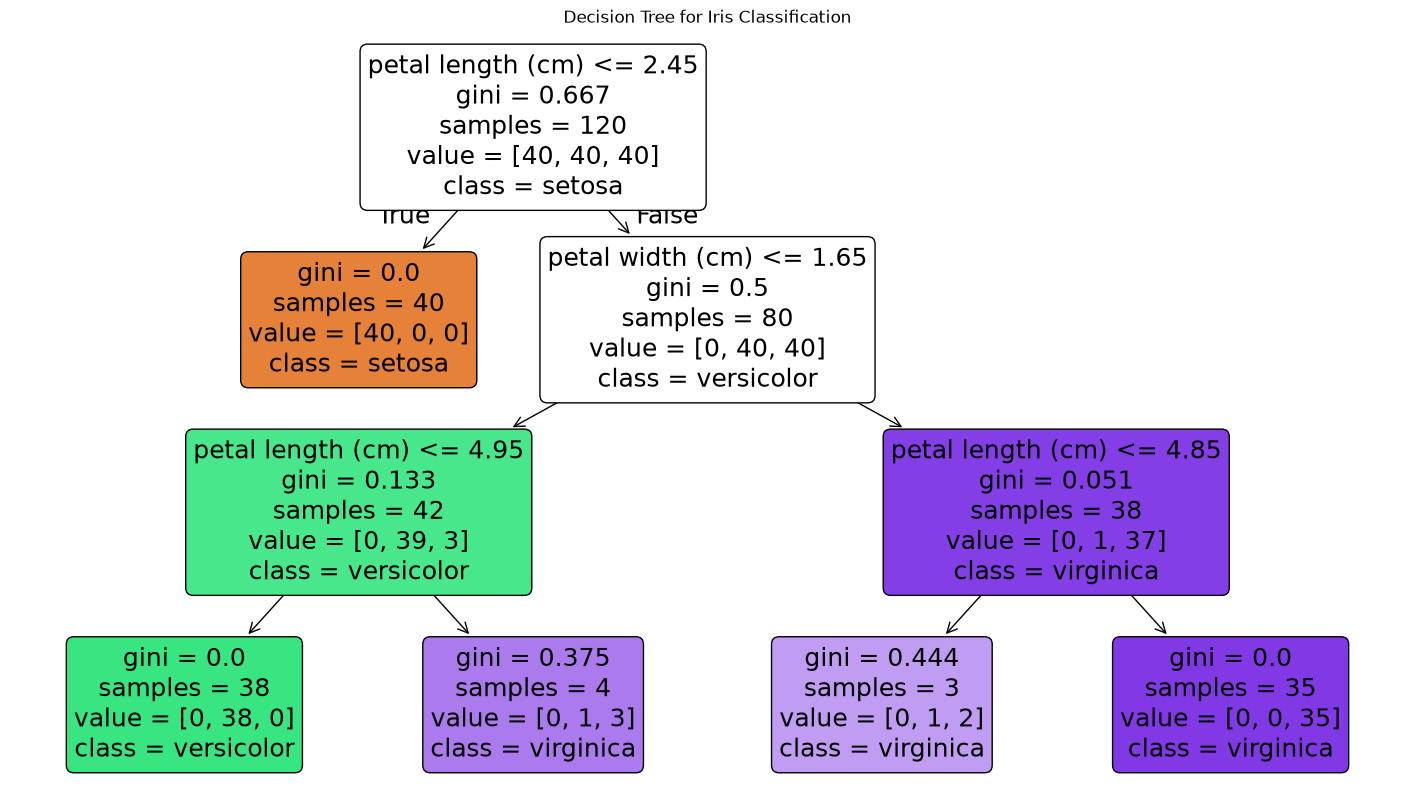

In [45]:
#DECICION TREE VISUALISATION:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    dt_model,
    feature_names=features,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)

plt.title("Decision Tree for Iris Classification")
plt.show()

## Model 4: Random Forest

Random Forest is an ensemble learning algorithm that combines multiple
Decision Trees to make predictions.

It generally provides robust performance and reduces the overfitting risk
associated with a single Decision Tree.

In [46]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [47]:
print("Random Forest")
print("-" * 50)

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf, average="weighted"))

print("Recall:",
      recall_score(y_test, y_pred_rf, average="weighted"))

print("F1-Score:",
      f1_score(y_test, y_pred_rf, average="weighted"))

Random Forest
--------------------------------------------------
Accuracy: 0.9
Precision: 0.9023569023569024
Recall: 0.9
F1-Score: 0.8997493734335839


In [48]:
print("Random Forest")
print("-" * 50)

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf, average="weighted"))

print("Recall:",
      recall_score(y_test, y_pred_rf, average="weighted"))

print("F1-Score:",
      f1_score(y_test, y_pred_rf, average="weighted"))

Random Forest
--------------------------------------------------
Accuracy: 0.9
Precision: 0.9023569023569024
Recall: 0.9
F1-Score: 0.8997493734335839


In [49]:
#COMPARING ALL 4 MODELS:
models = {
    "Logistic Regression": logistic_model,
    "KNN": knn_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():
    
    predictions = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted"
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted"
        ),
        "F1-Score": f1_score(
            y_test,
            predictions,
            average="weighted"
        )
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
1,KNN,0.933333,0.944444,0.933333,0.932660
2,Decision Tree,0.966667,0.969697,0.966667,0.966583
3,Random Forest,0.900000,0.902357,0.900000,0.899749


In [50]:
#RESULTS AS PERCENTAGE:
results_display = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

for column in metric_columns:
    results_display[column] = (
        results_display[column] * 100
    ).round(2).astype(str) + "%"

results_display

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,93.33%,93.33%,93.33%,93.33%
1,KNN,93.33%,94.44%,93.33%,93.27%
2,Decision Tree,96.67%,96.97%,96.67%,96.66%
3,Random Forest,90.0%,90.24%,90.0%,89.97%


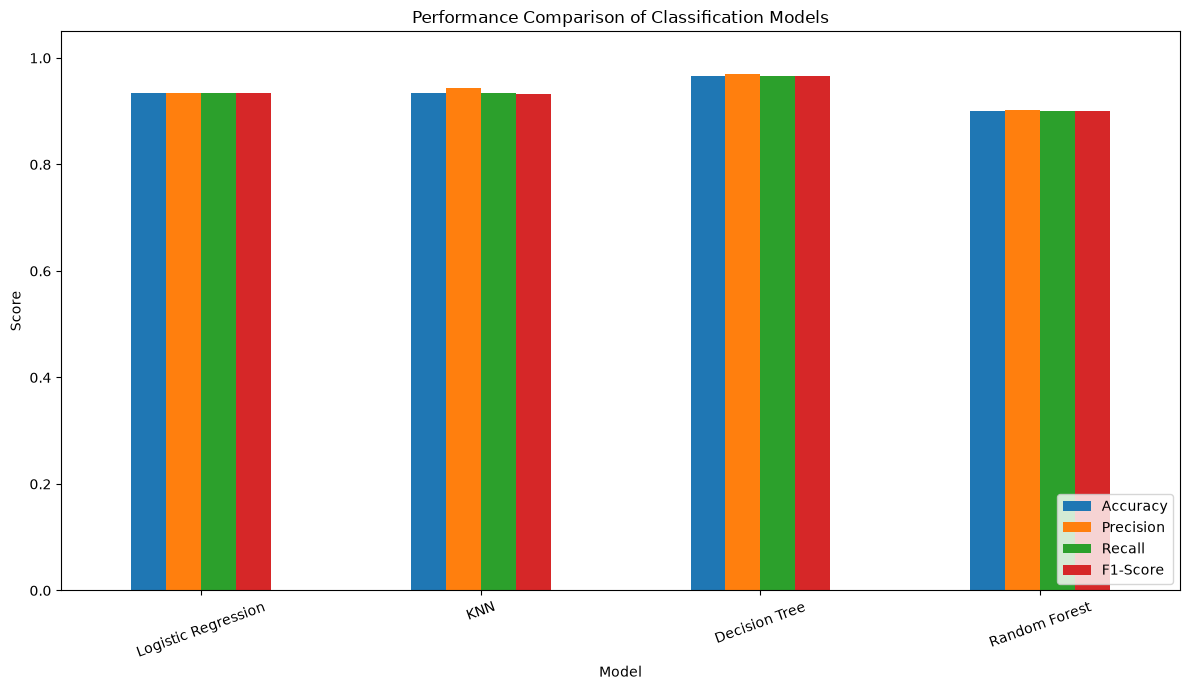

In [51]:
#MODEL COMPARISION VISUALIZATION:
results_plot = results_df.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Performance Comparison of Classification Models")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [52]:
##IDENTITY BEST MODEL:
best_model_row = results_df.loc[
    results_df["F1-Score"].idxmax()
]

print("Best Performing Model:")
print(best_model_row["Model"])

print("\nPerformance:")
print(best_model_row)

Best Performing Model:
Decision Tree

Performance:
Model        Decision Tree
Accuracy          0.966667
Precision         0.969697
Recall            0.966667
F1-Score          0.966583
Name: 2, dtype: object


## Final Model Selection

Based on the evaluation results, the Decision Tree achieved the highest
overall performance among the four tested models.

Its performance was approximately:

- Accuracy: 96.67%
- Precision: 96.97%
- Recall: 96.67%
- F1-Score: 96.66%

Therefore, the Decision Tree is selected as the best-performing model
for this particular train/test split.

The model performs well because the Iris dataset contains relatively
clear nonlinear decision boundaries, particularly for petal length and
petal width.

However, model performance can vary depending on the train/test split.
Therefore, cross-validation can be used as an additional step to obtain
a more reliable estimate of generalization performance.

In [55]:
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=features
)

prediction = model.predict(new_flower)

print("Predicted Species:", iris.target_names[prediction[0]])

Predicted Species: setosa
